# Classification

This notebook serves as supporting material for topics covered in **Chapter 18 - Learning from Examples**, **Chapter 19 - Knowledge in Learning**, **Chapter 20 - Learning Probabilistic Models** from the book *Artificial Intelligence: A Modern Approach*. Parts of the code are rewritten with library `scikit-learn` to provide hands-on implementation of the concepts. More information on `scikit-learn` can be found from [Official Website](https://scikit-learn.org/stable/index.html).

## Required libaray installation
Please make sure you have installed the required libraries before running the code below. Ensure you're in the `FAIens` environment, and install the required libraries by running the following command:
```shell
conda install -c conda-forge scikit-learn

or 

pip install scikit-learn
```

Let's start by importing everything from the module:

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn

## MACHINE LEARNING OVERVIEW

In this notebook, we learn about agents that can improve their behavior through diligent study of their own experiences.

An agent is **learning** if it improves its performance on future tasks after making observations about the world.

There are three types of feedback that determine the three main types of learning:

* **Supervised Learning**:

In Supervised Learning the agent observes some example input-output pairs and learns a function that maps from input to output.

Classification：‌Classification‌ is a fundamental supervised learning task that aims to ‌predict categorical labels‌ by learning patterns from labeled training data. Unlike regression (which predicts continuous values), classification outputs discrete classes (e.g., "spam/not spam," "dog/cat/bird").

**Example**: Let's think of an agent to classify images containing cats or dogs. If we provide an image containing a cat or a dog, this agent should output a string "cat" or "dog" for that particular image. To teach this agent, we will give a lot of input-output image pairs of cat and dog to the agent. The agent then learns a function that maps from an input image to one of those strings.


## DATASETS

For the following tutorials we will use a range of datasets, to better showcase the strengths and weaknesses of the algorithms. The datasests are the following:

* `Fisher's Iris`: Each item represents a flower, with four measurements: the length and the width of the sepals and petals. Each item/flower is categorized into one of three species: Setosa, Versicolor and Virginica.
* `Wine`: The data is the results of a chemical analysis of wines grown in the same region in Italy by three different cultivators. There are thirteen different measurements taken for different constituents found in the three types of wine.

### Importing a Dataset

#### Iris dataset

In this section, we will import the Iris dataset by using the scikit-learn library with the following code:

In [38]:
from sklearn import datasets

iris_dataset = datasets.load_iris()

This data sets consists of 3 different types of irises’ (Setosa, Versicolour, and Virginica) petal and sepal length, stored in a 150x4 numpy.ndarray

The following code shows the description of the Iris dataset:

In [39]:
print(iris_dataset.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

To check that we imported the correct dataset, we can do the following:

In [40]:
print(iris_dataset.data[0])
print(iris_dataset.target[0])

[5.1 3.5 1.4 0.2]
0


Which correctly prints the first element of data and its corresponding label.

### Attributes

Here we showcase the attributes.

First we will print the first three items/examples in the dataset. `iris.data` represents the attributes of the flowers and `iris.target` represents the target/label (species of the flower).

In [41]:
print(iris_dataset.data[0:3])
print(iris_dataset.target[0:3])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
[0 0 0]


Then we will print `target_names`, `feature_names`. In this case, `target_name` represent the iris species and `feature_names` represent the measurements of the flowers.

In [42]:
print(iris_dataset.target_names)
print(iris_dataset.feature_names)

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### Data Manipulation

We will now take a look at how to manipulate the data.

First, we will print the shape of the data. This will show us the number of items/examples and the number of attributes. For `iris` dataset, it contains 150 items/examples, with 4 attributes each. Please note that, for the shape of the target, `(150,)` means that it is a one-dimensional array with 150 labels/targets.

In [43]:
print(iris_dataset.data.shape)
print(iris_dataset.target.shape)

(150, 4)
(150,)


To build up classifiers, we usually split the data into two sets: the training set and the testing set. We will use the training set to train the model and the testing set to evaluate the model's performance. For the following tutorials, we use `X` to represent the attributes and `y` to represent the target.

As an example, we will use the first 15 items as the test set and the rest as the training set:

In [44]:
iris_dataset_train_X = iris_dataset.data[0:15] # slice from 1st element to the 15th element
iris_dataset_train_y = iris_dataset.target[0:15] # slice from 1st element to the 15th element
iris_dataset_test_X = iris_dataset.data[15:] # slice from 16th element to the end
iris_dataset_test_y = iris_dataset.target[15:] # slice from 16th element to the end

print(iris_dataset_train_X.shape)
print(iris_dataset_train_y.shape)
print(iris_dataset_test_X.shape)
print(iris_dataset_test_y.shape)

(15, 4)
(15,)
(135, 4)
(135,)


Besides, `sklearn` library provides a function `train_test_split` to split the data into training and test sets. The following code shows how to randomly split the data into training and test sets, with 20% of the data used for testing:

In [45]:
from sklearn.model_selection import train_test_split
# set random seed to 1, so that we can reproduce the results
iris_dataset_train_X, iris_dataset_test_X, iris_dataset_train_y, iris_dataset_test_y = train_test_split(iris_dataset.data, iris_dataset.target, test_size=0.2, random_state=1)

print(iris_dataset_train_X.shape)
print(iris_dataset_train_y.shape)
print(iris_dataset_test_X.shape)
print(iris_dataset_test_y.shape)

(120, 4)
(120,)
(30, 4)
(30,)


Other operations like `shuffle` could also be performed on the data. We will show them in the following sections.

## Visualization

Since we will use the iris dataset extensively in this notebook, below we visualize it that helps in comprehending the dataset and thus how the algorithms work.

We plot the dataset in a 3D space using `matplotlib`:

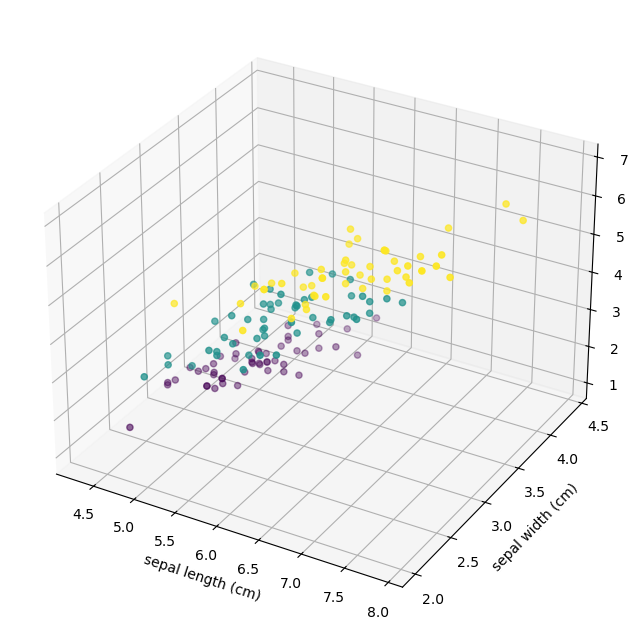

In [46]:
plt.figure(figsize=(12,8)) # set the size of the plot
ax = plt.axes(projection='3d') # 3D plot
ax.scatter(iris_dataset.data[:,0], iris_dataset.data[:,1], iris_dataset.data[:,2], c=iris_dataset.target) # plot the data points for 3 features, with color as target
ax.set_xlabel(iris_dataset.feature_names[0]) # set x-axis label
ax.set_ylabel(iris_dataset.feature_names[1])
ax.set_zlabel(iris_dataset.feature_names[2])
plt.show() # show the plot

## LINEAR LEARNER

### Overview

Linear Learner is a model that assumes a linear relationship between the input variables X and the single output variable y. More specifically, that y can be calculated from a linear combination of the input variables X. Linear learner is a quite simple model as the representation of this model is a linear equation.  

The linear equation assigns one scaler factor to each input value or column, called a coefficients or weights. One additional coefficient is also added, giving additional degree of freedom and is often called the intercept or the bias coefficient.   

### Implementation

`LinearRegression` fits a linear model to minimize the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation:

In [47]:
from sklearn.linear_model import LinearRegression

reg_clf = LinearRegression()
reg_clf.fit(iris_dataset_train_X, iris_dataset_train_y)

example = [[7.5, 2.5, 6.5, 2.0]]
predict_result = reg_clf.predict(example)
print(predict_result)

[1.95013924]


Note: The predict result is not a class label, but a continuous value. We choose the class label by rounding the continuous value:

In [48]:
label = round(predict_result[0]) # round the result to the nearest integer
print(iris_dataset.target_names[label])

virginica


## K-NEAREST NEIGHBOURS CLASSIFIER

### Overview
The k-Nearest Neighbors algorithm is a non-parametric method used for classification and regression. We are going to use this to classify Iris flowers. More about kNN on [Scholarpedia](http://www.scholarpedia.org/article/K-nearest_neighbor).

![kNN plot](images/knn_plot.png)

Let's see how kNN works with a simple plot shown in the above picture.

We have co-ordinates (we call them **features** in Machine Learning) of this red star and we need to predict its class using the kNN algorithm. In this algorithm, the value of **k** is arbitrary. **k** is one of the **hyper parameters** for kNN algorithm. We choose this number based on our dataset and choosing a particular number is known as **hyper parameter tuning/optimising**. We learn more about this in coming topics.

Let's put **k = 3**. It means you need to find 3-Nearest Neighbors of this red star and classify this new point into the majority class. Observe that smaller circle which contains three points other than **test point** (red star). As there are two violet points, which form the majority, we predict the class of red star as **violet- Class B**.

Similarly if we put **k = 5**, you can observe that there are three yellow points, which form the majority. So, we classify our test point as **yellow- Class A**.

In practical tasks, we iterate through a bunch of values for k (like [1, 3, 5, 10, 20, 50, 100]), see how it performs and select the best one. 

### Implementation

Neighbors-based classification is a type of instance-based learning or non-generalizing learning: it does not attempt to construct a general internal model, but simply stores instances of the training data. Classification is computed from a simple majority vote of the nearest neighbors of each point: a query point is assigned the data class which has the most representatives within the nearest neighbors of the point.

### Example

In the example, we measured a new flower with the following values: [5.1, 3.0, 1.1, 0.1]. To classify it, we construct a kNN classifier with 3 neighbors:

In [49]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=3)
knn_clf.fit(iris_dataset_train_X, iris_dataset_train_y)

example = [[5.1, 3.5, 1.4, 0.2]]
predict_result = knn_clf.predict(example)
print(iris_dataset.target_names[predict_result[0]])


setosa


The output of the above code is "setosa", which means the flower with the above measurements is of the "setosa" species.

## Decision Trees

### Overview

Decision Trees (DTs) are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. A tree can be seen as a piecewise constant approximation.

### Implementation

`DecisionTreeClassifier` is the class capable of performing multi-class classification on a dataset:

In [50]:
from sklearn import tree

decision_tree_clf = tree.DecisionTreeClassifier(criterion='entropy')
decision_tree_clf = decision_tree_clf.fit(iris_dataset_train_X, iris_dataset_train_y)

example = [[7.5, 2.5, 6.5, 2.0]]
predict_result = decision_tree_clf.predict(example)
print(iris_dataset.target_names[predict_result[0]])

virginica


### Visualization
We can visualize the decision tree with the following code:

[Text(0.4, 0.9166666666666666, 'petal length (cm) <= 2.6\nentropy = 1.581\nsamples = 120\nvalue = [39, 37, 44]\nclass = virginica'),
 Text(0.3, 0.75, 'entropy = 0.0\nsamples = 39\nvalue = [39, 0, 0]\nclass = setosa'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'petal width (cm) <= 1.65\nentropy = 0.995\nsamples = 81\nvalue = [0, 37, 44]\nclass = virginica'),
 Text(0.45, 0.8333333333333333, '  False'),
 Text(0.2, 0.5833333333333334, 'petal length (cm) <= 4.95\nentropy = 0.469\nsamples = 40\nvalue = [0, 36, 4]\nclass = versicolor'),
 Text(0.1, 0.4166666666666667, 'entropy = 0.0\nsamples = 35\nvalue = [0, 35, 0]\nclass = versicolor'),
 Text(0.3, 0.4166666666666667, 'sepal length (cm) <= 6.05\nentropy = 0.722\nsamples = 5\nvalue = [0, 1, 4]\nclass = virginica'),
 Text(0.2, 0.25, 'petal width (cm) <= 1.55\nentropy = 1.0\nsamples = 2\nvalue = [0, 1, 1]\nclass = versicolor'),
 Text(0.1, 0.08333333333333333, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),


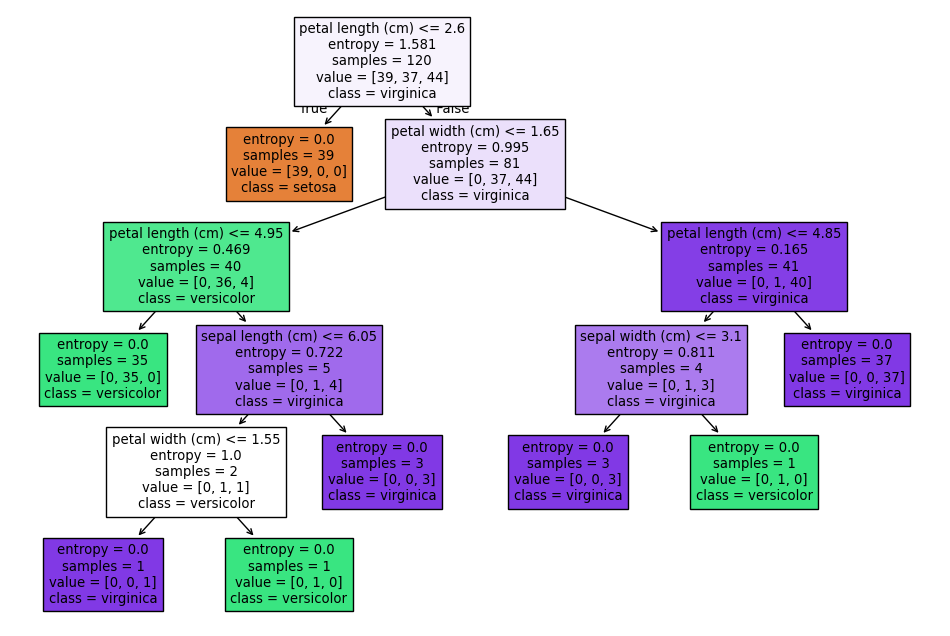

In [51]:
plt.figure(figsize=(12,8))
tree.plot_tree(decision_tree_clf, class_names=iris_dataset.target_names.tolist(), feature_names=iris_dataset.feature_names, filled=True)

## Logistic Regression

### Overview

Logistic regression is a discriminant approach for binary classification. In this model, the probabilities describing the possible outcomes of a single trial are modeled using a logistic function.


### Implementation

The model `LogisticRegression` could be used to classify both binary and multi-class classification problems. In this example, we set the `multi_class` parameter to `multinomial` to perform multi-class classification.

In [52]:
from sklearn.linear_model import LogisticRegression
params = {'max_iter': 100, 'random_state': 0}
try:
    # For older versions of scikit-learn, we need to specify the multi_class parameter
    logistic_clf = LogisticRegression(multi_class='multinomial', **params)
except TypeError:
    # For newer versions of scikit-learn, the multi_class parameter is not needed
    logistic_clf = LogisticRegression(**params)
    
logistic_clf.fit(iris_dataset_train_X, iris_dataset_train_y)

example = [[7.5, 2.5, 6.5, 2.0]]
predict_result = logistic_clf.predict(example)
print(iris_dataset.target_names[predict_result[0]])

virginica


/opt/anaconda3/envs/fai/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Naive Bayes

### Overview

Naive Bayes is a generative multi-class approach based on applying Bayes’ theorem with the “naive” assumption of conditional independence. It computes the probability for each class based on the training data.


### Implementation

We choose to use the `GaussianNB` model to perform classification in this class. The likelihood of the features is assumed to be Gaussian:
$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma^2_y}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma^2_y}\right)$$
The parameters $\sigma_y$ and $\mu_y$ are estimated using maximum likelihood.

In [53]:
from sklearn.naive_bayes import GaussianNB

gnb_clf = GaussianNB()
gnb_clf.fit(iris_dataset_train_X, iris_dataset_train_y)

example = [[7.5, 2.5, 6.5, 2.0]]
predict_result = gnb_clf.predict(example)
print(iris_dataset.target_names[predict_result[0]])

virginica


## LEARNER EVALUATION

In this section we will evaluate and compare different algorithms' performance. We will use the `score` method to evaluate the performance of the algorithms. The score method returns the mean accuracy on the given test data and labels.

First, we will use kNN with different values of *k*. Note that *k* should have odd values, to break any ties between two classes.

In [54]:
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_5 = KNeighborsClassifier(n_neighbors=5)

iris_dataset_train_X, iris_dataset_test_X, iris_dataset_train_y, iris_dataset_test_y = train_test_split(iris_dataset.data, iris_dataset.target, test_size=0.2)

knn_1.fit(iris_dataset_train_X, iris_dataset_train_y)
knn_3.fit(iris_dataset_train_X, iris_dataset_train_y)
knn_5.fit(iris_dataset_train_X, iris_dataset_train_y)

knn_1_score = knn_1.score(iris_dataset_test_X, iris_dataset_test_y)
knn_3_score = knn_3.score(iris_dataset_test_X, iris_dataset_test_y)
knn_5_score = knn_5.score(iris_dataset_test_X, iris_dataset_test_y)

print(knn_1_score)
print(knn_3_score)
print(knn_5_score)

1.0
1.0
1.0


Then, we evaluate the performance of all algorithms which we have implemented above:

In [55]:
print(reg_clf.score(iris_dataset_test_X, iris_dataset_test_y))
print(decision_tree_clf.score(iris_dataset_test_X, iris_dataset_test_y))
print(logistic_clf.score(iris_dataset_test_X, iris_dataset_test_y))
print(gnb_clf.score(iris_dataset_test_X, iris_dataset_test_y))

0.9200298054153448
1.0
1.0
1.0


Notice that the score may vary depending on the training and test sets. To get a more accurate evaluation, we can use the `cross_val_score` function from the `model_selection` module. This function splits the data into *k* folds, trains the model on *k-1* of them and evaluates it on the remaining fold. This process is repeated *k* times (the folds), with each of the *k* folds used exactly once as the test data. The function returns an array of scores.

In [56]:
from sklearn.model_selection import cross_val_score

iris_dataset_X = iris_dataset.data
iris_dataset_y = iris_dataset.target

# shuffle the dataset
indices = np.random.permutation(len(iris_dataset_X))
iris_dataset_X = iris_dataset_X[indices]
iris_dataset_y = iris_dataset_y[indices]

# cross validation, specify the number of folds as 5
scores_knn_1 = cross_val_score(knn_1, iris_dataset_X, iris_dataset_y, cv=5)
scores_knn_3 = cross_val_score(knn_3, iris_dataset_X, iris_dataset_y, cv=5)
scores_knn_5 = cross_val_score(knn_5, iris_dataset_X, iris_dataset_y, cv=5)

# print the scores and the mean value
print(scores_knn_1, np.mean(scores_knn_1))
print(scores_knn_3, np.mean(scores_knn_3))
print(scores_knn_5, np.mean(scores_knn_5))

[0.93333333 0.96666667 0.96666667 0.93333333 0.96666667] 0.9533333333333334
[0.93333333 0.96666667 1.         0.93333333 0.96666667] 0.96
[0.93333333 0.96666667 1.         0.96666667 0.93333333] 0.96


## EXERCISES

The `wine` dataset is the results of a chemical analysis of wines grown in the same region in Italy by three different cultivators. There are thirteen different measurements taken for different constituents found in the three types of wine.

Your task is to classify the wines into one of the three cultivators using the methods we have learned in this notebook. Please follow the guidelines below:

In [57]:
''' load the wine dataset '''
wine = datasets.load_wine()
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [58]:
"""print the feature names"""
#todo

print(wine.feature_names)

"""print the class names"""
#todo

print(wine.target_names)

"""separate the dataset into training and testing sets, with 70% of the data for training and 30% for testing"""
#todo

from sklearn.model_selection import train_test_split

wine_train_X, wine_test_X, wine_train_y, wine_test_y = train_test_split(wine.data, wine.target, test_size=0.7, random_state=1)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


In [62]:
"""linear regression"""
#todo

from sklearn.linear_model import LinearRegression

reg_wine = LinearRegression()
reg_wine.fit(wine_train_X, wine_train_y)

predict_reg_wine = np.round(reg_wine.predict(wine_test_X))
print("Linear Regression accuracy:", np.mean(predict_reg_wine == wine_test_y))

Linear Regression accuracy: 0.864


In [63]:
"""kNN classifier with k=3"""
#todo

from sklearn.neighbors import KNeighborsClassifier

knn_wine = KNeighborsClassifier(n_neighbors=3)
knn_wine.fit(wine_train_X, wine_train_y)

predict_knn_wine = knn_wine.predict(wine_test_X)
print("KNN accuracy:", np.mean(predict_knn_wine == wine_test_y))

KNN accuracy: 0.688


Decision Tree accuracy: 0.912


[Text(0.5, 0.9, 'flavanoids <= 1.4\nentropy = 1.584\nsamples = 53\nvalue = [18, 18, 17]\nclass = class_0'),
 Text(0.25, 0.7, 'color_intensity <= 3.81\nentropy = 0.702\nsamples = 21\nvalue = [0, 4, 17]\nclass = class_2'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4, 0]\nclass = class_1'),
 Text(0.375, 0.5, 'entropy = 0.0\nsamples = 17\nvalue = [0, 0, 17]\nclass = class_2'),
 Text(0.75, 0.7, 'proline <= 730.0\nentropy = 0.989\nsamples = 32\nvalue = [18, 14, 0]\nclass = class_0'),
 Text(0.625, 0.8, '  False'),
 Text(0.625, 0.5, 'hue <= 0.855\nentropy = 0.353\nsamples = 15\nvalue = [1, 14, 0]\nclass = class_1'),
 Text(0.5, 0.3, 'nonflavanoid_phenols <= 0.37\nentropy = 1.0\nsamples = 2\nvalue = [1, 1, 0]\nclass = class_0'),
 Text(0.375, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0, 0]\nclass = class_0'),
 Text(0.625, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1, 0]\nclass = class_1'),
 Text(0.75, 0.3, 'entropy = 0.0\nsamples = 13\nvalue = 

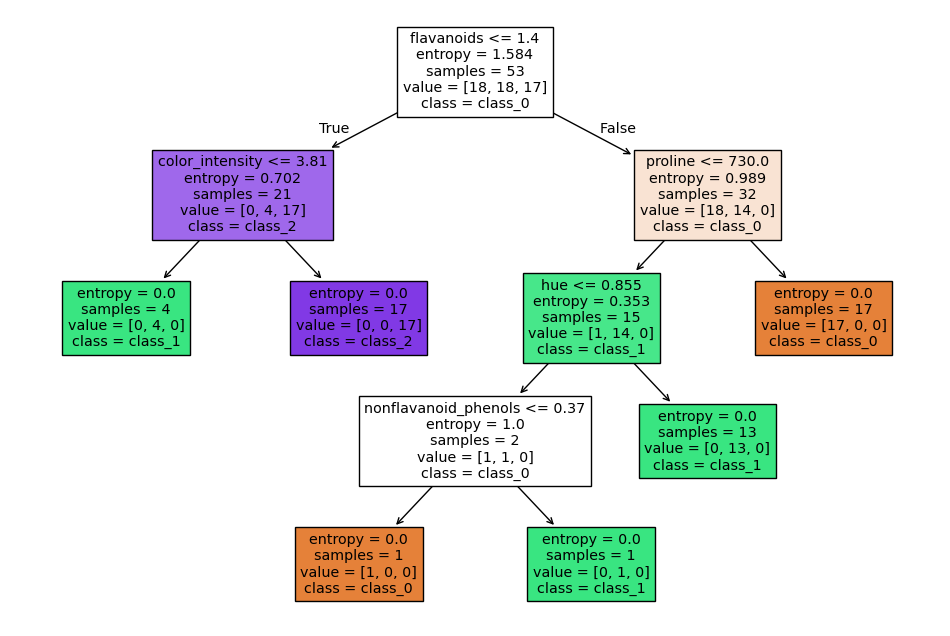

In [65]:
"""decision tree"""
#todo

from sklearn import tree

tree_wine = tree.DecisionTreeClassifier(criterion='entropy')
tree_wine = tree_wine.fit(wine_train_X, wine_train_y)

predict_tree_wine = tree_wine.predict(wine_test_X)
print("Decision Tree accuracy:", np.mean(predict_tree_wine == wine_test_y))

plt.figure(figsize=(12,8))
tree.plot_tree(tree_wine, class_names=wine.target_names.tolist(), feature_names=wine.feature_names, filled=True)

In [66]:
"""logistic regression"""
#todo

from sklearn.linear_model import LogisticRegression

params = {'max_iter': 100, 'random_state': 0}

try:
    logistic_wine = LogisticRegression(multi_class='multinomial', **params)
except TypeError:
    logistic_wine = LogisticRegression(**params)
    
logistic_wine.fit(wine_train_X, wine_train_y)

predict_logistic_wine = logistic_wine.predict(wine_test_X)
print("Logistic Regression accuracy:", np.mean(predict_logistic_wine == wine_test_y))

Logistic Regression accuracy: 0.92


/opt/anaconda3/envs/fai/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/fai/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [67]:
"""naive bayes"""
#todo

from sklearn.naive_bayes import GaussianNB

gnb_wine = GaussianNB()
gnb_wine.fit(wine_train_X, wine_train_y)

predict_gnb_wine = gnb_wine.predict(wine_test_X)
print("Naive Bayes accuracy:", np.mean(predict_gnb_wine == wine_test_y))

Naive Bayes accuracy: 0.968
